# Curso 1 — Agente ReAct com LangGraph + Busca Web

Este projeto demonstra um agente que usa o LangGraph para controlar o fluxo
entre uma LLM da Groq e a ferramenta externa de busca Tavily.

Conceitos apresentados:
- **Estado:** histórico compartilhado em `MessagesState`.
- **Nós:** etapas que executam a LLM ou uma ferramenta.
- **Arestas:** conexões que definem a ordem do fluxo.
- **Ferramentas:** recursos externos que a LLM pode solicitar.
- **Roteamento:** escolha condicional entre usar a ferramenta ou encerrar.
- **Ciclos:** retorno de `tools` para `agent`.
- **ReAct:** raciocínio, ação, observação e nova análise até a resposta final.

In [5]:
import os
from pathlib import Path

from dotenv import load_dotenv

def _project_dir() -> Path:
    """Localiza esta pasta tanto no script quanto no kernel do notebook."""
    if "__file__" in globals():
        return Path(__file__).resolve().parent
    candidates = [
        Path.cwd(),
        Path.cwd() / "experiments" / "01-langgraph" / "agente-busca-tavily",
    ]
    return next(
        (path for path in candidates if (path / "agente_busca_tavily.py").exists()),
        Path.cwd(),
    )


BASE_DIR = _project_dir()
REPO_ROOT = next(
    (path for path in (BASE_DIR, *BASE_DIR.parents) if (path / "experiments").is_dir()),
    BASE_DIR,
)
load_dotenv(REPO_ROOT / ".env")
load_dotenv(BASE_DIR / ".env", override=False)


PLACEHOLDER_KEYS = {
    "",
    "cole_sua_chave_aqui",
    "sua_chave_aqui",
    "sua_chave_groq",
    "sua_chave_tavily",
}


def chave_configurada(nome: str) -> bool:
    """Distingue uma credencial real de valores vazios e placeholders."""
    return os.getenv(nome, "").strip().lower() not in PLACEHOLDER_KEYS


def validar_configuracao() -> None:
    """Exige Groq; Tavily é opcional e habilita a busca web quando presente."""
    if not chave_configurada("GROQ_API_KEY"):
        raise EnvironmentError(
            "Configuração ausente: GROQ_API_KEY. Configure a chave no .env da "
            "raiz antes de executar."
        )


validar_configuracao()
TAVILY_DISPONIVEL = chave_configurada("TAVILY_API_KEY")
print("Configuração Groq carregada.")
print(
    "Busca Tavily habilitada."
    if TAVILY_DISPONIVEL
    else (
        "TAVILY_API_KEY ausente ou com placeholder: executando sem busca web. "
        "Adicione uma chave Tavily ao .env para habilitar o ciclo ReAct."
    )
)

Configuração Groq carregada.
TAVILY_API_KEY ausente ou com placeholder: executando sem busca web. Adicione uma chave Tavily ao .env para habilitar o ciclo ReAct.


In [6]:
from typing import Any

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

In [7]:
# O nome fica no .env para permitir a troca do modelo sem alterar o código.
MODEL_NAME = os.getenv("GROQ_MODEL", "llama-3.3-70b-versatile").removeprefix("groq/")

model = ChatGroq(
    model=MODEL_NAME,
    api_key=os.environ["GROQ_API_KEY"],
    temperature=0,
    timeout=60,
    max_retries=2,
)

In [8]:
# A Tavily acessa informações externas e atuais. A LLM decide quando chamá-la.
search_tool = (
    TavilySearch(max_results=4, topic="general") if TAVILY_DISPONIVEL else None
)
tools = [search_tool] if search_tool is not None else []
model_with_tools = model.bind_tools(tools) if tools else model

In [9]:
SYSTEM_PROMPT = """
Você é um agente de pesquisa cuidadoso. Siga estas regras:
1. Se a pergunta depender de informações externas ou atuais, use a busca Tavily.
2. Se o contexto já tiver informação suficiente, responda diretamente.
3. Depois de usar uma ferramenta, analise os resultados antes de responder.
4. Não invente informações; informe claramente quando não houver evidência.
5. Responda sempre em português.
6. Seja objetivo e mencione as fontes consultadas quando possível.
""".strip()
if not TAVILY_DISPONIVEL:
    SYSTEM_PROMPT += """

A busca Tavily não está configurada nesta execução. Responda apenas com conhecimento
geral do modelo, não alegue ter pesquisado a web e avise quando a pergunta depender
de informações atuais.
""".rstrip()

In [10]:
def agent_node(state: MessagesState) -> dict[str, list[Any]]:
    """Executa a LLM e acrescenta a resposta ao histórico compartilhado."""
    mensagens = [SystemMessage(content=SYSTEM_PROMPT), *state["messages"]]

    try:
        resposta = model_with_tools.invoke(mensagens)
    except Exception as erro:
        # A exceção original é preservada como causa para facilitar o diagnóstico.
        raise RuntimeError(
            "Falha ao consultar a Groq. Verifique a chave, o modelo, "
            "a conexão e os limites da sua conta. "
            f"Detalhe: {type(erro).__name__}: {erro}"
        ) from erro

    if not resposta.content and not resposta.tool_calls:
        raise RuntimeError("A Groq retornou uma resposta vazia e sem tool call.")

    return {"messages": [resposta]}

In [11]:
def should_continue(state: MessagesState) -> str:
    """Escolhe Tools quando há tool calls; caso contrário, encerra o grafo."""
    ultima_mensagem = state["messages"][-1]
    return "tools" if getattr(ultima_mensagem, "tool_calls", None) else END

In [12]:
def tratar_erro_ferramenta(erro: Exception) -> str:
    """Devolve o erro ao agente sem ocultar seu tipo ou sua mensagem."""
    return (
        "ERRO AO EXECUTAR A TAVILY. "
        f"{type(erro).__name__}: {erro}. "
        "Não invente resultados; explique a falha ao usuário."
    )


builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_edge(START, "agent")
if tools:
    builder.add_node(
        "tools",
        ToolNode(tools, handle_tool_errors=tratar_erro_ferramenta),
    )
    builder.add_conditional_edges(
        "agent",
        should_continue,
        {"tools": "tools", END: END},
    )
    builder.add_edge("tools", "agent")  # Cria o ciclo ReAct.
else:
    builder.add_edge("agent", END)

agent = builder.compile()

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



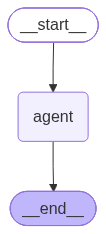

In [13]:
if __name__ == "__main__":
    mermaid = agent.get_graph().draw_mermaid()
    print(mermaid)

    # A imagem é opcional: uma falha não impede o agente de funcionar.
    try:
        from IPython.display import Image, display

        display(Image(agent.get_graph().draw_mermaid_png()))
    except Exception as erro:
        print(
            "Visualização PNG indisponível. O Mermaid acima continua válido. "
            f"Detalhe: {type(erro).__name__}: {erro}"
        )

In [14]:
PERGUNTA_TESTE = (
    "Pesquise na web o que é LangGraph e explique em três pontos qual o papel "
    "dele na construção de agentes de IA."
    if TAVILY_DISPONIVEL
    else (
        "Com base no seu conhecimento geral, explique em três pontos qual é o "
        "papel do LangGraph na construção de agentes de IA."
    )
)


def texto_da_mensagem(mensagem: Any) -> str:
    """Extrai texto de uma mensagem e detecta respostas finais vazias."""
    conteudo = getattr(mensagem, "content", "")
    if isinstance(conteudo, str):
        texto = conteudo
    elif isinstance(conteudo, list):
        # Alguns modelos devolvem blocos de conteúdo em vez de uma string.
        texto = "\n".join(
            str(bloco.get("text", ""))
            for bloco in conteudo
            if isinstance(bloco, dict) and bloco.get("text")
        )
    else:
        texto = ""
    if not texto or not str(texto).strip():
        raise RuntimeError("O agente terminou, mas a resposta final está vazia.")
    return str(texto).strip()


def executar_agente(pergunta: str) -> dict[str, list[Any]]:
    """Executa o grafo e converte falhas gerais em mensagens didáticas."""
    if not pergunta.strip():
        raise ValueError("A pergunta não pode estar vazia.")

    try:
        return agent.invoke({"messages": [HumanMessage(content=pergunta)]})
    except Exception as erro:
        if isinstance(erro, (RuntimeError, ValueError)):
            raise
        raise RuntimeError(
            "Não foi possível concluir o grafo. Verifique a conexão, as chaves "
            f"e os serviços externos. Detalhe: {type(erro).__name__}: {erro}"
        ) from erro


if __name__ == "__main__":
    resultado = executar_agente(PERGUNTA_TESTE)
    print(texto_da_mensagem(resultado["messages"][-1]))

Infelizmente, não tenho conhecimento específico sobre o LangGraph e seu papel na construção de agentes de IA. Posso sugerir que o LangGraph possa ser uma ferramenta ou uma biblioteca relacionada à linguagem natural, mas não tenho informações suficientes para fornecer uma resposta precisa.

Se você puder fornecer mais contexto ou informações sobre o LangGraph, posso tentar ajudar melhor.


In [15]:
if __name__ == "__main__":
    print("\nFLUXO COMPLETO DA EXECUÇÃO")
    for numero, mensagem in enumerate(resultado["messages"], start=1):
        if mensagem.type == "human":
            descricao = "PERGUNTA DO USUÁRIO"
        elif mensagem.type == "ai" and getattr(mensagem, "tool_calls", None):
            descricao = "DECISÃO DA LLM: USAR FERRAMENTA / TOOL CALL"
        elif mensagem.type == "tool":
            descricao = "RESULTADO DA TAVILY / OBSERVATION"
        else:
            descricao = "RESPOSTA FINAL DA LLM"

        print(f"\n--- Etapa {numero}: {descricao} ---")
        if hasattr(mensagem, "pretty_print"):
            mensagem.pretty_print()
        else:
            print(mensagem)


FLUXO COMPLETO DA EXECUÇÃO

--- Etapa 1: PERGUNTA DO USUÁRIO ---
================================ Human Message =================================

Com base no seu conhecimento geral, explique em três pontos qual é o papel do LangGraph na construção de agentes de IA.

--- Etapa 2: RESPOSTA FINAL DA LLM ---
================================== Ai Message ==================================

Infelizmente, não tenho conhecimento específico sobre o LangGraph e seu papel na construção de agentes de IA. Posso sugerir que o LangGraph possa ser uma ferramenta ou uma biblioteca relacionada à linguagem natural, mas não tenho informações suficientes para fornecer uma resposta precisa.

Se você puder fornecer mais contexto ou informações sobre o LangGraph, posso tentar ajudar melhor.


## Explicação acadêmica

**`MessagesState`** mantém o estado da conversa. Seu campo `messages` usa um
redutor que acrescenta novas mensagens ao histórico em vez de apagar as antigas.

**`agent_node`** é o nó em que a LLM lê o contexto, raciocina e decide se deve
responder ou solicitar uma ferramenta por meio de `tool_calls`.

**`ToolNode`** executa as ferramentas solicitadas e adiciona a observação da
ferramenta ao estado como uma mensagem.

**`should_continue`** implementa o roteamento condicional: segue para `tools`
quando existe uma chamada de ferramenta e para `END` quando existe uma resposta.

**`tools → agent`** cria o ciclo. Após observar o resultado, a LLM raciocina
novamente e pode buscar mais informações ou produzir a resposta final.

LangGraph não é a LLM. **LangGraph** orquestra o fluxo; a **LLM** raciocina e
gera respostas; a **Tavily** acessa informações externas.

O padrão **ReAct** aparece assim:

1. **Reasoning:** o modelo analisa o problema.
2. **Action:** o modelo decide usar uma ferramenta.
3. **Observation:** o modelo recebe o resultado da ferramenta.
4. **Reasoning:** o modelo analisa novamente o contexto atualizado.
5. **Final Answer:** o modelo gera a resposta final.